In [1]:
from pauli_funct import *

Some example code here, just as a demo

In [2]:
rho0= pa.PauliArray.from_labels('IIIIIIIIZIIIIIII')
print(rho0.inspect())
print()
# Here, the PauliArray type obect is created from a string of "labelled" Pauli matrices, including the 2x2 identity, so IXYZ. 
# from_labels is the PauliArray method that performs this

rho0 = op.Operator.from_paulis_and_weights(rho0, 1)
print(rho0.inspect())
print()
# Here, the Operator type object is created by taking in weighted PauliArray(s)
# from_paulis_and_weights is the PauliArray method that performs this

PauliArray
IIIIIIIIZIIIIIII

Operator
Sum of
(+1.0000 +0.0000j) IIIIIIIIZIIIIIII



Beginning of the actual code from here

In [3]:
seed_str = 'X'
pad_width = 2

padded_seed = 'I'*pad_width + seed_str + 'I'*pad_width
n = len(padded_seed)        # total number of qubits

o0 = pa.PauliArray.from_labels(padded_seed)         # in this case, 5 I's, X, 5 I's or IIIIIXIIIII

print(o0.inspect())
print()

o0_op = op.Operator.from_paulis_and_weights(o0, 1)

print(o0_op.inspect())
print()

PauliArray
IIXII

Operator
Sum of
(+1.0000 +0.0000j) IIXII



In [4]:
edges = [(k,(k+1)% n) for k in range(n)]        
print(edges)
print()
# So for example, if n==11 (no of qubits), then edges would be a list of tuples from [(0,1), (1,2), ... (10,0)] since the last element is up to but not including.
# In each tuple, the number inside is the qubit that that operator will act on. For example, (0,1) means that Qubit0 and Qubit1 will have "True" for the Z or X string.

[(0, 1), (1, 2), (2, 3), (3, 4), (4, 0)]



In [5]:
# Initialise a 2D array (a "matrix") of 0s for all these, Bool type where 0 == False
ising_z = np.zeros((len(edges), n), dtype=bool)                     
# print(ising_z)
# print()
ising_x = np.zeros((len(edges), n), dtype=bool)
ff1_z = np.zeros((len(edges), n), dtype=bool)
ff1_x = np.zeros((len(edges), n), dtype=bool)
ff2_z = np.zeros((len(edges), n), dtype=bool)
ff2_x = np.zeros((len(edges), n), dtype=bool)

for idx, edge in enumerate(edges):
    # print([idx, edge])
    # print()                  
    ising_z[idx, edge] = True                   # for the 2D array, the first element indicates the row(s) to act, and the second element the column(s) to act on. In this case, one row (from idx) and two columns (from edge, which is a 2-element tuple)
    ff1_x[idx, edge] = True
    ff2_z[idx, edge] = True
    ff2_x[idx, edge] = True

print(ising_z)
print()

ising_hamiltonian = op.Operator.from_paulis_and_weights(pa.PauliArray(ising_z, ising_x), 1)         
ff1_hamiltonian = op.Operator.from_paulis_and_weights(pa.PauliArray(ff1_z, ff1_x), -0.5)
ff2_hamiltonian = op.Operator.from_paulis_and_weights(pa.PauliArray(ff2_z, ff2_x), -0.5)

print(ising_hamiltonian.inspect())      # It's just Sum of ZiZi+1 over all i in a ring of qubits
print()
print(ff1_hamiltonian.inspect())        # first part of flip flop hamiltonian as seen in spin chains exercise
print()
print(ff2_hamiltonian.inspect())        # second part of flip flop hamiltonian as seen in spin chains exercise
print("=========================")

# ========================================================
# # This hamiltonian is exactly the same as seen in the operator evolution and XXZ hamiltonian exercise

# The following three statements are equivalent (use truth test with print statements to verify this)
# ham1 = ising_hamiltonian+ff1_hamiltonian+ff2_hamiltonian     
# ham2 = (ising_hamiltonian.add_operator(ff1_hamiltonian)).add_operator(ff2_hamiltonian)
ham = ising_hamiltonian.__add__(ff1_hamiltonian).__add__(ff2_hamiltonian)
# print(ham1 == ham2)
# print(ham2 == ham3)
# print("=========================")

print(ham.inspect())

[[ True  True False False False]
 [False  True  True False False]
 [False False  True  True False]
 [False False False  True  True]
 [ True False False False  True]]

Operator
Sum of
(+1.0000 +0.0000j) IIIZZ
(+1.0000 +0.0000j) IIZZI
(+1.0000 +0.0000j) IZZII
(+1.0000 +0.0000j) ZZIII
(+1.0000 +0.0000j) ZIIIZ

Operator
Sum of
(-0.5000 +0.0000j) IIIXX
(-0.5000 +0.0000j) IIXXI
(-0.5000 +0.0000j) IXXII
(-0.5000 +0.0000j) XXIII
(-0.5000 +0.0000j) XIIIX

Operator
Sum of
(-0.5000 +0.0000j) IIIYY
(-0.5000 +0.0000j) IIYYI
(-0.5000 +0.0000j) IYYII
(-0.5000 +0.0000j) YYIII
(-0.5000 +0.0000j) YIIIY
Operator
Sum of
(-0.5000 +0.0000j) XXIII
(-0.5000 +0.0000j) IXXII
(-0.5000 +0.0000j) IIXXI
(-0.5000 +0.0000j) XIIIX
(-0.5000 +0.0000j) IIIXX
(+1.0000 +0.0000j) ZZIII
(-0.5000 +0.0000j) YYIII
(+1.0000 +0.0000j) IZZII
(-0.5000 +0.0000j) IYYII
(+1.0000 +0.0000j) IIZZI
(-0.5000 +0.0000j) IIYYI
(+1.0000 +0.0000j) ZIIIZ
(-0.5000 +0.0000j) YIIIY
(+1.0000 +0.0000j) IIIZZ
(-0.5000 +0.0000j) IIIYY


In [6]:
edge1 = [(2,3)]
edge2 = [(3,4)]

ham1 = generate_dipole_hamiltonian(len(padded_seed), neighbor_list=edge1)
ham2 = generate_dipole_hamiltonian(len(padded_seed), neighbor_list=edge2)

print(ham1.inspect())
print()
print(ham2.inspect())
print()
# Remember the printouts are based on little-endian counting

Operator
Sum of
(-0.5000 +0.0000j) IXXII
(+1.0000 +0.0000j) IZZII
(-0.5000 +0.0000j) IYYII

Operator
Sum of
(-0.5000 +0.0000j) XXIII
(+1.0000 +0.0000j) ZZIII
(-0.5000 +0.0000j) YYIII



In [7]:
print(op.commutator(ham1, ham2).inspect())
print()

Operator
Sum of
(+0.0000 +1.0000j) ZYXII
(+0.0000 +0.5000j) YZXII
(+0.0000 -1.0000j) XYZII
(+0.0000 +1.0000j) YXZII
(+0.0000 -0.5000j) XZYII
(+0.0000 -1.0000j) ZXYII



# Liouvillian graph
Christopher White's papers are the most detailed explanations of these, including the meaning of the vertices and edges etc inside the graph. \
Keep in mind that these graphs are DIFFERENT from the graphs described in the PauliArray documentation, as shown here: https://algolab-quantique.github.io/pauliarray/tutorials/commutators.html. The graphs in this documentation refer to qubit nodes with edge interactions.

When the initial (t=0) Pauli string evolves in time (Heisenberg picture, operators evolve) via the Liouville equation, what happens is that it will become some new Pauli string. This new Pauli string, can be decomposed into more Pauli strings using equation (14) of White's paper. 

So each time step, the Pauli string will go from one node to another with some weight (see equation (14)); if we were to sum up the weights and the destination Pauli strings, we would acquire the total new Pauli string. 

The trace of (sigma^mu * Comm(sigma^nu, Hamiltonian)) is known as the Hilbert Schmidt inner product. This inner product gives (something proportional to) the weight of the component of the evolution into each new Pauli string, as determined by the Liouvillian superoperator, as seen in equation (16) of White's paper.

In [8]:
### Test Louiville graph with a bunch of print functions
graph, label_map = generate_louivillian_graph(padded_seed, ham, depth=2, max_nodes=1000)

Layer: 0

label: IIXII

o_next: Operator
Sum of
(+0.0000 +1.0000j) IYZII
(+0.0000 +2.0000j) IZYII
(+0.0000 +2.0000j) IIYZI
(+0.0000 +1.0000j) IIZYI

Layer: 1

label: IYZII

o_next: Operator
Sum of
(+0.0000 -2.0000j) IXIII
(+0.0000 -1.0000j) IIXII
(+0.0000 -2.0000j) ZXZII
(+0.0000 -1.0000j) XZZII
(+0.0000 +1.0000j) IYYXI
(+0.0000 -1.0000j) IYXYI

label: IZYII

o_next: Operator
Sum of
(+0.0000 -1.0000j) IXIII
(+0.0000 -2.0000j) IIXII
(+0.0000 -1.0000j) YXYII
(+0.0000 +1.0000j) XYYII
(+0.0000 -1.0000j) IZZXI
(+0.0000 -2.0000j) IZXZI

label: IIYZI

o_next: Operator
Sum of
(+0.0000 -2.0000j) IIXII
(+0.0000 -1.0000j) IIIXI
(+0.0000 -2.0000j) IZXZI
(+0.0000 -1.0000j) IXZZI
(+0.0000 +1.0000j) IIYYX
(+0.0000 -1.0000j) IIYXY

label: IIZYI

o_next: Operator
Sum of
(+0.0000 -1.0000j) IIXII
(+0.0000 -2.0000j) IIIXI
(+0.0000 -1.0000j) IYXYI
(+0.0000 +1.0000j) IXYYI
(+0.0000 -1.0000j) IIZZX
(+0.0000 -2.0000j) IIZXZ



Now time to visualise this as a graph!

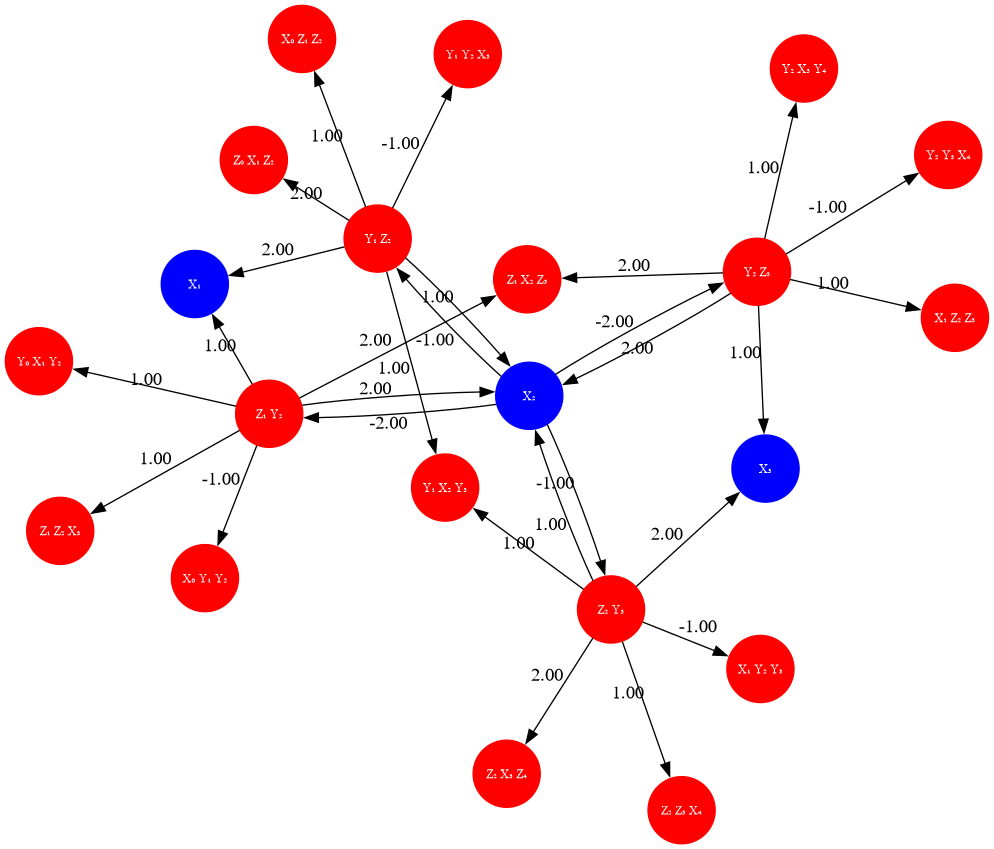

In [9]:
graphviz_draw(graph, node_attr_fn=node_attr, edge_attr_fn=edge_attr, method='sfdp')

Create an adjacency matrix for this graph.   
Note that @ is the matrix multiplication operator in Python!

In [10]:
chain_mat = rx.adjacency_matrix(graph, weight_fn= lambda x: x).T        # Create the Liouville graph's associated adjacency matrix; easy for rustworks to do

# Example usage with the notebook's variables:
n = chain_mat.shape[0]      # rows of the adjacency matrix
A0 = np.zeros(n)            # Just create 
A0[0] = 1.0                 # set initial occupancy on the root node (root_idx exists in the notebook)

times = np.linspace(0.0, 10.0, 100)  # adjust as needed

A_t = solve_chain_time_series(chain_mat, A0, times, max_step=0.001)

# print a small summary
print("A(t) shape:", A_t.shape)
print("A(0) :", A_t[0])     # confirms that A_t[0] == A0 as we wanted

A(t) shape: (100, 21)
A(0) : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Make another graph 
Using a new Hamiltonian

In [11]:
seed_str = 'Z'
pad_width = 3
padded_seed = 'I'*pad_width + seed_str + 'I'*pad_width
ham = generate_dq_hamiltonian(len(padded_seed))
#ham = generate_xxz_hamiltonian(len(padded_seed),delta=-2)
root_idx = 0  # since seed is the first node added

Layer: 0

label: IIIZIII

o_next: Operator
Sum of
(+0.0000 -2.0000j) IIYXIII
(+0.0000 -2.0000j) IIXYIII
(+0.0000 -2.0000j) IIIYXII
(+0.0000 -2.0000j) IIIXYII

Layer: 1

label: IIYXIII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIZIIII
(+0.0000 +2.0000j) IXZXIII
(+0.0000 +2.0000j) IIIZIII
(+0.0000 +2.0000j) IIYZYII

label: IIXYIII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIZIIII
(+0.0000 +2.0000j) IIIZIII
(+0.0000 +2.0000j) IIXZXII
(+0.0000 +2.0000j) IYZYIII

label: IIIYXII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIIZIII
(+0.0000 +2.0000j) IIXZXII
(+0.0000 +2.0000j) IIIIZII
(+0.0000 +2.0000j) IIIYZYI

label: IIIXYII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIIZIII
(+0.0000 +2.0000j) IIIIZII
(+0.0000 +2.0000j) IIIXZXI
(+0.0000 +2.0000j) IIYZYII

Layer: 2

label: IIZIIII

o_next: Operator
Sum of
(+0.0000 -2.0000j) IYXIIII
(+0.0000 -2.0000j) IXYIIII
(+0.0000 -2.0000j) IIYXIII
(+0.0000 -2.0000j) IIXYIII

label: IXZXIII

o_next: Operator
Sum of
(+0.0000 -2.0000j) IXYIIII
(+0.0000 

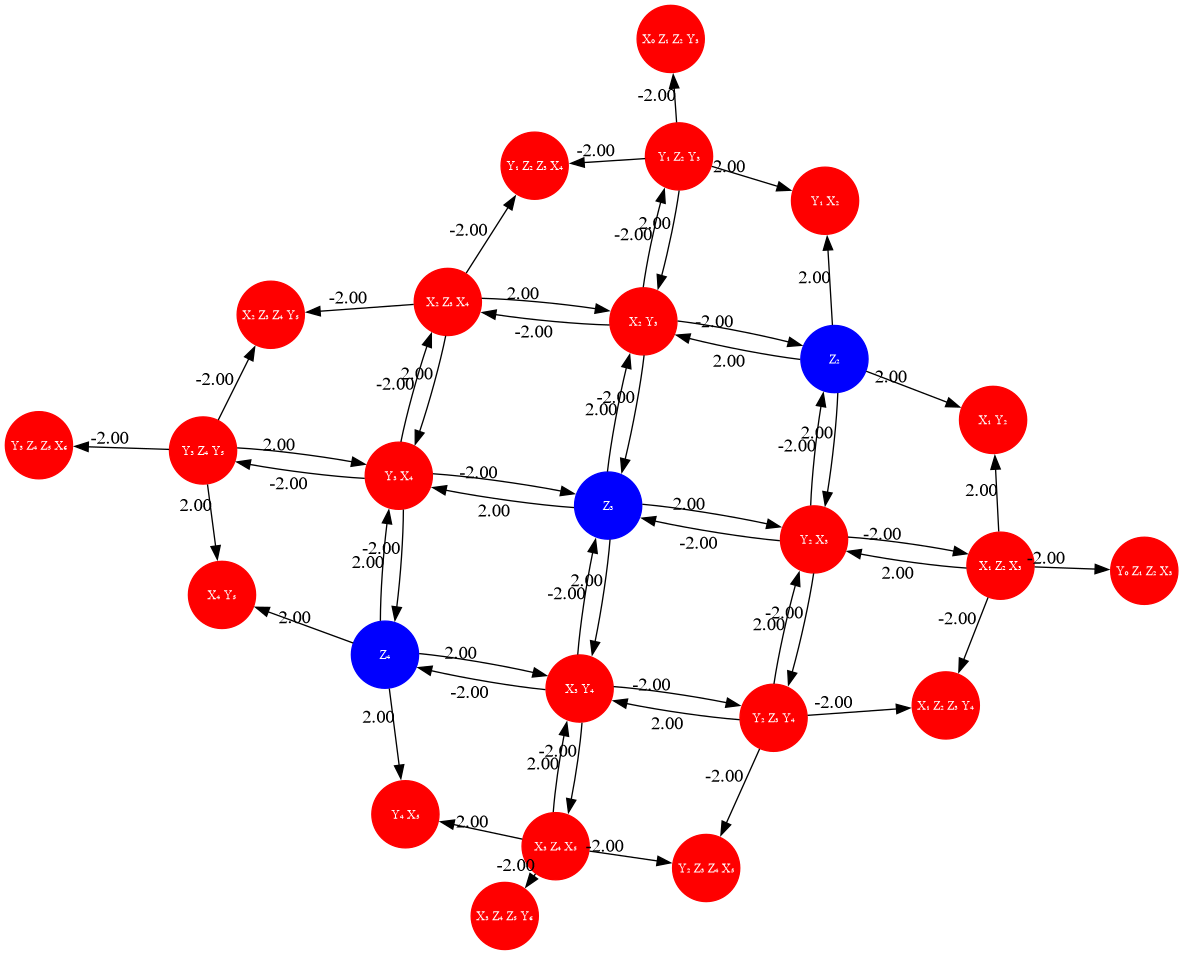

In [12]:
graph_2, label_map_2 = generate_louivillian_graph(padded_seed, ham, depth=3, corr_cutoff=4, max_nodes=100000, directed=True)
graphviz_draw(graph_2, node_attr_fn=node_attr, edge_attr_fn=edge_attr, method='sfdp')

In [13]:
chain_mat_2 =  rx.adjacency_matrix(graph_2, weight_fn= lambda x: x).T

# Example usage with the notebook's variables:
n = chain_mat_2.shape[0]
A0 = np.zeros(n)
print(chain_mat_2)
A0[0] = 1.0     # set initial occupancy on the root node (root_idx exists in the notebook)

times = np.linspace(0.0, 10.0, 100)  # adjust as needed
A_t = solve_chain_time_series(chain_mat_2, A0, times,max_step=0.001)

# print a small summary
print("A(t) shape:", A_t.shape)
print("A(0) :", A_t[0])     # initial adjacency matrix at 0 time

[[ 0. -2. -2. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  2.  2.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  2.  0.  0.  2.  2.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  0.  0.  0.  2.  0.  2.  2.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  0.  0.  2.  0.  0.  2.  0.  2.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0. -2.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  

Plotting the amplitude of the single Z Pauli strings

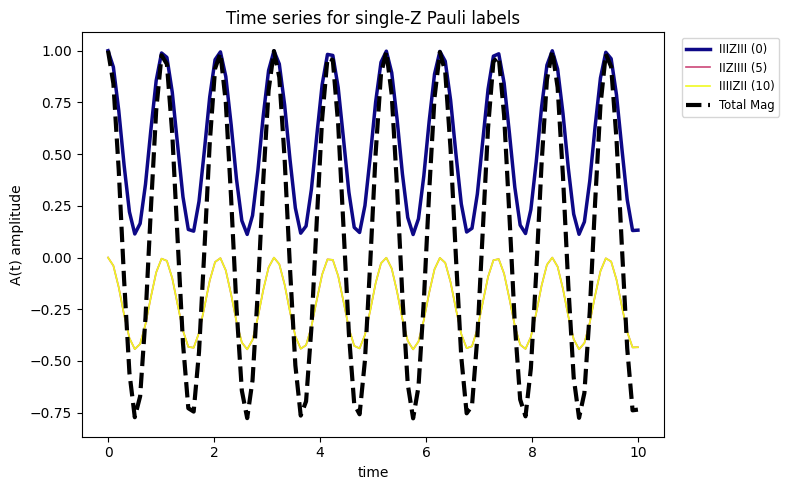

In [14]:
# Filter for labels with exactly one 'Z'
zi_items = [(lab, idx) for lab, idx in label_map_2.items() if set(lab) <= {"I", "Z"}]       # Only if the label contains I's and Z's
single_z_items = [(lab, idx) for lab, idx in zi_items if lab.count('Z') == 1]               # within those that are only I's and Z's, consider those with only one Z

if not single_z_items:
    print("No single-Z labels found in zi_items.")
    
else:
    # Sort by node index for stable ordering
    single_z_items = sorted(single_z_items, key=lambda x: x[1])

    labels = [lab for lab, _ in single_z_items]
    idxs = [idx for _, idx in single_z_items]

    total_z = np.zeros(len(times))

    plt.figure(figsize=(8, 5))

    cmap = plt.get_cmap("plasma")

    for k, (lab, idx) in enumerate(zip(labels, idxs)):
        color = cmap(k / max(1, len(labels) - 1))       # create a "colour gradient" using this cmap
        lw = 2.5 if idx == root_idx else 1.2            # define some linewidth
        total_z += A_t[:, idx]                          # The entire column of index idx in adjacency matrix A_t; this column corresponds to the single z pauli string of the iteration 
        plt.plot(times, A_t[:, idx], label=f"{lab} ({idx})", color=color, linewidth=lw)     # plotting that particular column over all time

    plt.plot(times, total_z, label="Total Mag", color="black", linewidth=3, linestyle="--")
    plt.xlabel("time")
    plt.ylabel("A(t) amplitude")
    plt.title("Time series for single-Z Pauli labels")
    plt.legend(fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Coherence = superposition of quantum states that differ in energy that maintains a constant phase. Single quantum coherence corresponds to a superposition between two energy levels; multiple quantum coherence indicates more energy levels in our superposition.

In [15]:
# # Compute MQC intensities
# mqc_intensity = {}
# for label, idx in label_map_2.items():
#     mqc_orders = pauli_to_mqc(label)
#     for order, coeff in mqc_orders.items():
#         if order not in mqc_intensity:
#             mqc_intensity[order] = np.zeros(len(times),dtype=np.complex128)
#         mqc_intensity[order] += coeff * A_t[:, idx]

# mqc_intensity = {order: np.abs(intensity)**2 for order, intensity in mqc_intensity.items()}
# # Create a 3D wire plot for MQC intensities

# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# orders = sorted(mqc_intensity.keys())
# X, Y = np.meshgrid(times, orders)
# Z = np.array([mqc_intensity[order] for order in orders])

# for i in range(len(orders)):
#     ax.plot(times, [orders[i]] * len(times), Z[i], label=f"Order {orders[i]}")

# ax.set_xlabel("Time")
# ax.set_ylabel("MQC Order")
# ax.set_zlabel("Intensity")
# ax.set_title("3D Wire Plot of MQC Intensities")
# plt.legend(fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
# plt.show()


{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}


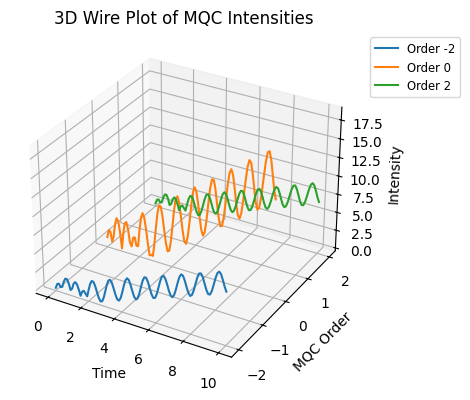

In [16]:
plot_mqc_from_label_map(label_map_2, A_t, times)

Repeated action for the double quantum hamiltonian

In [17]:
pad=15
padded_seed = 'I'*pad + 'Z' + 'I'*pad

dq = generate_dq_hamiltonian(len(padded_seed))
graph_dq, label_map_dq = generate_louivillian_graph(padded_seed, dq, depth=len(padded_seed)*2, corr_cutoff=len(padded_seed), max_nodes=100000, directed=True)    

graphviz_draw(graph_dq, node_attr_fn=node_attr, edge_attr_fn=edge_attr, method='sfdp')

A0 = np.zeros(len(label_map_dq))
A0[0] = 1.0  # initial occupancy on root node
times = np.linspace(0.0, 5.0, 500)  
A_t = compute_time_evolution(graph_dq, A0, times)

Layer: 0

label: IIIIIIIIIIIIIIIZIIIIIIIIIIIIIII

o_next: Operator
Sum of
(+0.0000 -2.0000j) IIIIIIIIIIIIIIYXIIIIIIIIIIIIIII
(+0.0000 -2.0000j) IIIIIIIIIIIIIIXYIIIIIIIIIIIIIII
(+0.0000 -2.0000j) IIIIIIIIIIIIIIIYXIIIIIIIIIIIIII
(+0.0000 -2.0000j) IIIIIIIIIIIIIIIXYIIIIIIIIIIIIII

Layer: 1

label: IIIIIIIIIIIIIIYXIIIIIIIIIIIIIII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIIIIIIIIIIIIIZIIIIIIIIIIIIIIII
(+0.0000 +2.0000j) IIIIIIIIIIIIIXZXIIIIIIIIIIIIIII
(+0.0000 +2.0000j) IIIIIIIIIIIIIIIZIIIIIIIIIIIIIII
(+0.0000 +2.0000j) IIIIIIIIIIIIIIYZYIIIIIIIIIIIIII

label: IIIIIIIIIIIIIIXYIIIIIIIIIIIIIII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIIIIIIIIIIIIIZIIIIIIIIIIIIIIII
(+0.0000 +2.0000j) IIIIIIIIIIIIIIIZIIIIIIIIIIIIIII
(+0.0000 +2.0000j) IIIIIIIIIIIIIIXZXIIIIIIIIIIIIII
(+0.0000 +2.0000j) IIIIIIIIIIIIIYZYIIIIIIIIIIIIIII

label: IIIIIIIIIIIIIIIYXIIIIIIIIIIIIII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIIIIIIIIIIIIIIZIIIIIIIIIIIIIII
(+0.0000 +2.0000j) IIIIIIIIIIIIIIXZXIIIIIIIIIIIIII
(+0.000

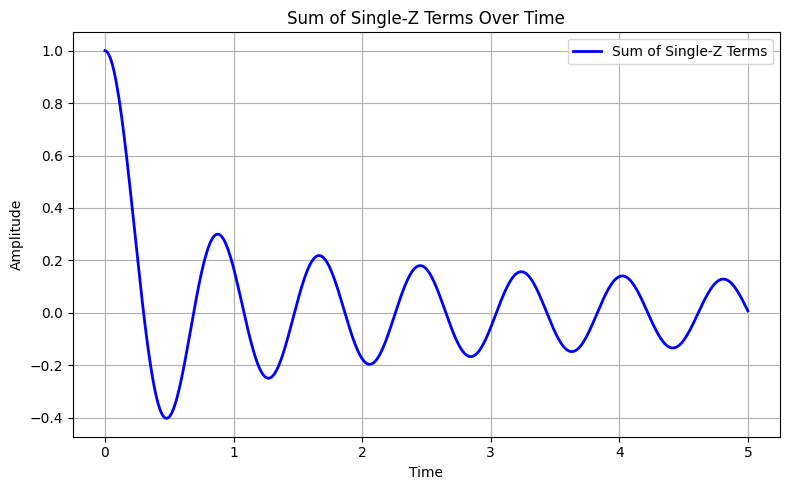

In [18]:
# Filter for labels with exactly one 'Z' and the rest 'I's
single_z_items = [(lab, idx) for lab, idx in label_map_dq.items() if set(lab) <= {"I", "Z"} and lab.count('Z') == 1]

if not single_z_items:
    print("No single-Z labels found in label_map_dq.")
else:
    # Extract indices for the relevant nodes
    idxs = [idx for _, idx in single_z_items]

    # Compute the sum of the corresponding terms in A_t
    total_single_z = np.sum(A_t[:, idxs], axis=1)

    # Plot the result
    plt.figure(figsize=(8, 5))
    plt.plot(times, total_single_z, label="Sum of Single-Z Terms", color="blue", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title("Sum of Single-Z Terms Over Time")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

Bessel function?

Fitted parameters: Amplitude = 0.9999999881617763, Frequency = 1.2732395467062447, Phase = -3.475827050977311e-08


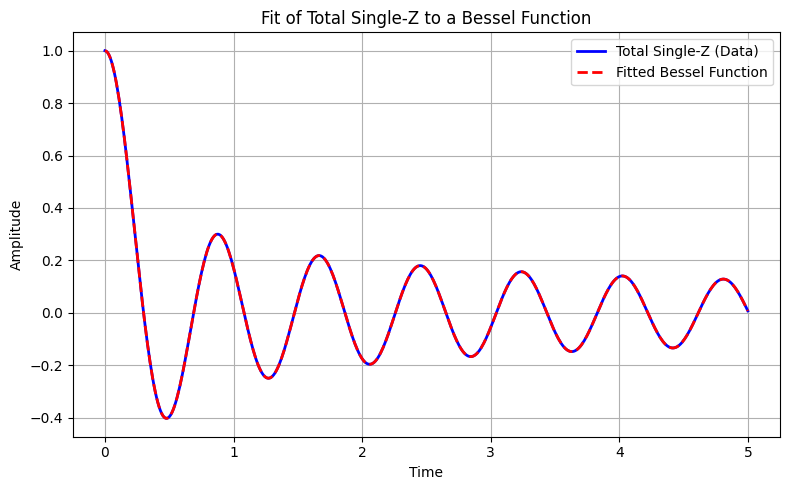

In [19]:
# Define the Bessel function model
def bessel_model(t, amplitude, frequency, phase):
    return amplitude * j0(2 * np.pi * frequency * t + phase)

# Perform the curve fitting
initial_guess = [1.0, 1.25, 0.0]  # Initial guesses for amplitude, frequency, and phase
params, covariance = curve_fit(bessel_model, times, total_single_z, p0=initial_guess)

# Extract the fitted parameters
amplitude_fit, frequency_fit, phase_fit = params
print(f"Fitted parameters: Amplitude = {amplitude_fit}, Frequency = {frequency_fit}, Phase = {phase_fit}")

# Generate the fitted curve
fitted_curve = bessel_model(times, amplitude_fit, frequency_fit, phase_fit)

# Plot the original data and the fitted curve
plt.figure(figsize=(8, 5))
plt.plot(times, total_single_z, label="Total Single-Z (Data)", color="blue", linewidth=2)
plt.plot(times, fitted_curve, label="Fitted Bessel Function", color="red", linestyle="--", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit of Total Single-Z to a Bessel Function")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{0: 1}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1, -2: 1, 0: 2}
{2: 1

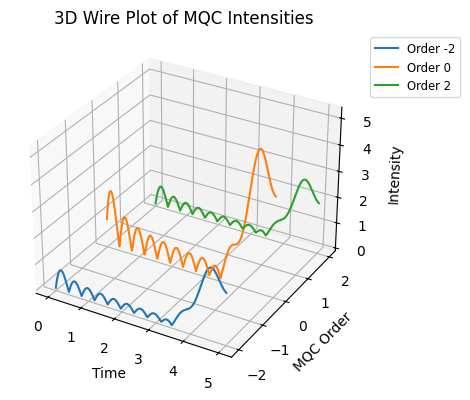

In [20]:
plot_mqc_from_label_map(label_map_dq, A_t, times)

# More graphs (moved down)

In [21]:

graph_3, label_map_3 = generate_louivillian_graph(padded_seed, ham, depth=10, corr_cutoff=4, max_nodes=1000, directed=True)
graphviz_draw(graph_3, node_attr_fn=node_attr, edge_attr_fn=edge_attr, method='sfdp')

Layer: 0

label: IIIIIIIIIIIIIIIZIIIIIIIIIIIIIII



ValueError: operands could not be broadcast together with shapes (14,1,14) (1,1,62) 

In [ ]:
chain_mat_3 =  rx.adjacency_matrix(graph_3,weight_fn= lambda x: x).T
# Example usage with the notebook's variables:
n = chain_mat_3.shape[0]
A0 = np.zeros(n)
# set initial occupancy on the root node (root_idx exists in the notebook)
A0[0] = 1.0

times = np.linspace(0.0, 10.0, 100)  # adjust as needed
A_t = solve_chain_time_series(chain_mat_3, A0, times,max_step=0.001)

NameError: name 'graph_3' is not defined

In [ ]:
# Filter for labels with exactly one 'Z'
zi_items = [(lab, idx) for lab, idx in label_map_3.items() if set(lab) <= {"I", "Z"}]
single_z_items = [(lab, idx) for lab, idx in zi_items if lab.count('Z') == 1]

if not single_z_items:
    print("No single-Z labels found in zi_items.")
else:
    # Sort by node index for stable ordering
    single_z_items = sorted(single_z_items, key=lambda x: x[1])
    labels = [lab for lab, _ in single_z_items]
    idxs = [idx for _, idx in single_z_items]

    total_z = np.zeros(len(times))
    plt.figure(figsize=(8, 5))
    cmap = plt.get_cmap("plasma")
    for k, (lab, idx) in enumerate(zip(labels, idxs)):
        color = cmap(k / max(1, len(labels) - 1))
        lw = 2.5 if idx == root_idx else 1.2
        total_z += A_t[:, idx]
        plt.plot(times, A_t[:, idx], label=f"{lab} ({idx})", color=color, linewidth=lw)

    plt.plot(times, total_z, label="Total Mag", color="black", linewidth=3, linestyle="--")
    plt.xlabel("time")
    plt.ylabel("A(t) amplitude")
    plt.title("Time series for single-Z Pauli labels")
    plt.legend(fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

NameError: name 'label_map_3' is not defined

In [ ]:
graph_4, label_map_4 = generate_louivillian_graph(padded_seed, ham, depth=10, corr_cutoff=5, max_nodes=1000, directed=True)

Layer: 0

label: IIIIIIIIIIIIIIIZIIIIIIIIIIIIIII



ValueError: operands could not be broadcast together with shapes (16,1,16) (1,1,62) 

In [ ]:
chain_mat_4 =  rx.adjacency_matrix(graph_4,weight_fn= lambda x: x).T
# Example usage with the notebook's variables:
n = chain_mat_4.shape[0]
A0 = np.zeros(n)
# set initial occupancy on the root node (root_idx exists in the notebook)
A0[0] = 1.0

times = np.linspace(0.0, 10.0, 100)  # adjust as needed
A_t = solve_chain_time_series(chain_mat_4, A0, times,max_step=0.001)

In [ ]:
# Filter for labels with exactly one 'Z'
zi_items = [(lab, idx) for lab, idx in label_map_4.items() if set(lab) <= {"I", "Z"}]
single_z_items = [(lab, idx) for lab, idx in zi_items if lab.count('Z') == 1]

if not single_z_items:
    print("No single-Z labels found in zi_items.")
else:
    # Sort by node index for stable ordering
    single_z_items = sorted(single_z_items, key=lambda x: x[1])
    labels = [lab for lab, _ in single_z_items]
    idxs = [idx for _, idx in single_z_items]

    total_z = np.zeros(len(times))
    plt.figure(figsize=(8, 5))
    cmap = plt.get_cmap("plasma")
    for k, (lab, idx) in enumerate(zip(labels, idxs)):
        color = cmap(k / max(1, len(labels) - 1))
        lw = 2.5 if idx == root_idx else 1.2
        total_z += A_t[:, idx]
        plt.plot(times, A_t[:, idx], label=f"{lab} ({idx})", color=color, linewidth=lw)

    plt.plot(times, total_z, label="Total Mag", color="black", linewidth=3, linestyle="--")
    plt.xlabel("time")
    plt.ylabel("A(t) amplitude")
    plt.title("Time series for single-Z Pauli labels")
    plt.legend(fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# XXZ

Layer: 0

label: IIIIIIIIIZIIIIIIIII

o_next: Operator
Sum of
(+0.0000 -1.0000j) IIIIIIIIYXIIIIIIIII
(+0.0000 +1.0000j) IIIIIIIIXYIIIIIIIII
(+0.0000 +1.0000j) IIIIIIIIIYXIIIIIIII
(+0.0000 -1.0000j) IIIIIIIIIXYIIIIIIII

Layer: 1

label: IIIIIIIIYXIIIIIIIII

o_next: Operator
Sum of
(+0.0000 -0.7500j) IIIIIIIZXXIIIIIIIII
(+0.0000 -1.0000j) IIIIIIIIZIIIIIIIIII
(+0.0000 -1.0000j) IIIIIIIXZXIIIIIIIII
(+0.0000 +1.0000j) IIIIIIIIIZIIIIIIIII
(+0.0000 +0.7500j) IIIIIIIIYYZIIIIIIII
(+0.0000 +1.0000j) IIIIIIIIYZYIIIIIIII

label: IIIIIIIIXYIIIIIIIII

o_next: Operator
Sum of
(+0.0000 +1.0000j) IIIIIIIIZIIIIIIIIII
(+0.0000 -1.0000j) IIIIIIIIIZIIIIIIIII
(+0.0000 -1.0000j) IIIIIIIIXZXIIIIIIII
(+0.0000 +1.0000j) IIIIIIIYZYIIIIIIIII
(+0.0000 +0.7500j) IIIIIIIZYYIIIIIIIII
(+0.0000 -0.7500j) IIIIIIIIXXZIIIIIIII

label: IIIIIIIIIYXIIIIIIII

o_next: Operator
Sum of
(+0.0000 -0.7500j) IIIIIIIIZXXIIIIIIII
(+0.0000 -1.0000j) IIIIIIIIIZIIIIIIIII
(+0.0000 -1.0000j) IIIIIIIIXZXIIIIIIII
(+0.0000 +1.0000j) IIIIIIIII

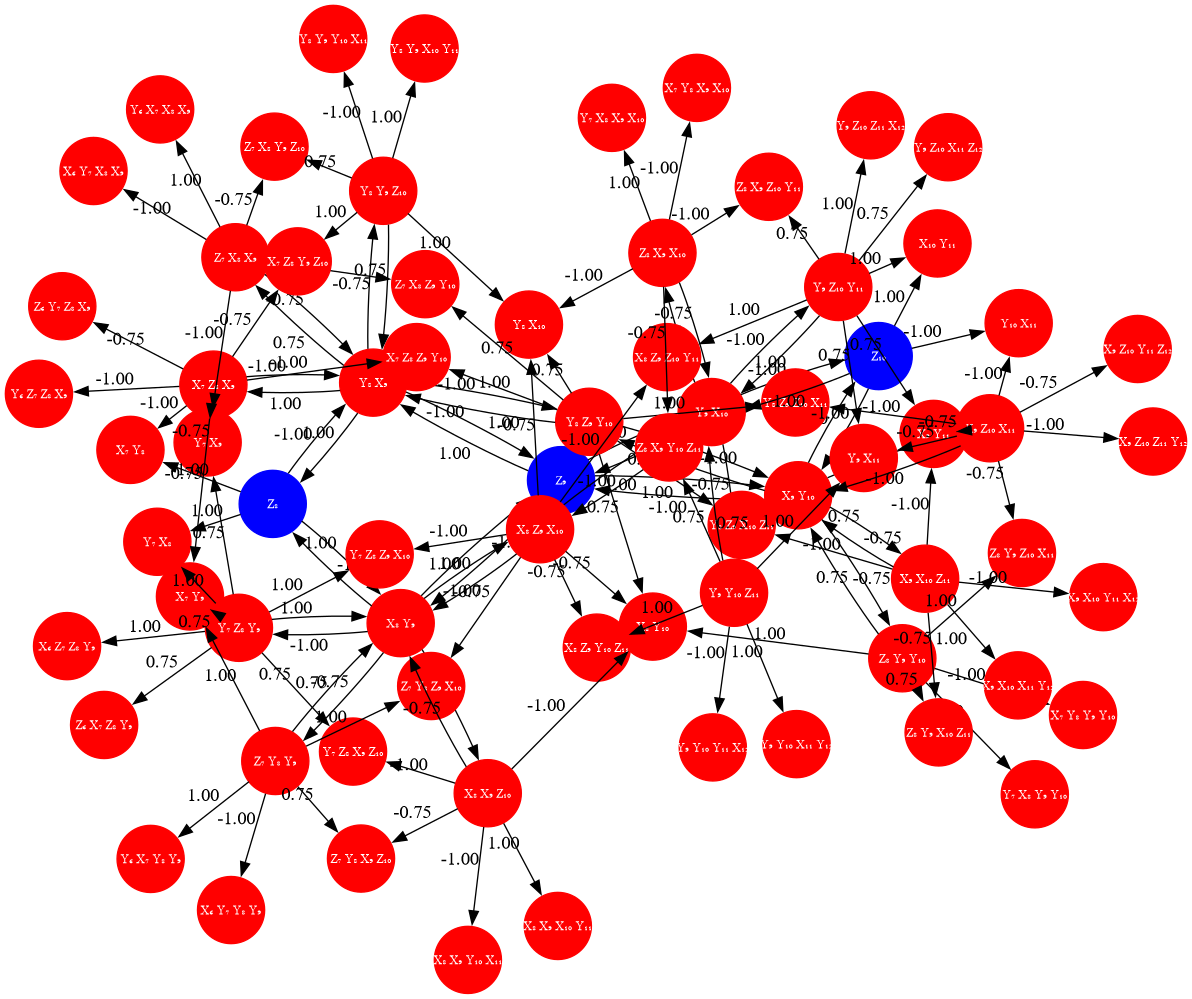

In [ ]:
seed_str = 'Z'
pad_width = 9
padded_seed = 'I'*pad_width + seed_str + 'I'*pad_width
ham = generate_xxz_hamiltonian(n=len(padded_seed), delta=-.75, J=1/2, h=0)
root_idx = 0  # since seed is the first node added

graph_2, label_map_2 = generate_louivillian_graph(padded_seed, ham, depth=3, corr_cutoff=4, max_nodes=100000, directed=True)
graphviz_draw(graph_2, node_attr_fn=node_attr, edge_attr_fn=edge_attr, method='sfdp')

# MQC

Layer: 0

label: IIZII

o_next: Operator
Sum of
(+0.0000 -2.0000j) IYXII
(+0.0000 -2.0000j) IXYII
(+0.0000 -2.0000j) IIYXI
(+0.0000 -2.0000j) IIXYI

Layer: 1

label: IYXII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IZIII
(+0.0000 +2.0000j) XZXII
(+0.0000 +2.0000j) IIZII
(+0.0000 +2.0000j) IYZYI

label: IXYII

o_next: Operator
Sum of
(+0.0000 +2.0000j) IZIII
(+0.0000 +2.0000j) IIZII
(+0.0000 +2.0000j) IXZXI
(+0.0000 +2.0000j) YZYII

label: IIYXI

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIZII
(+0.0000 +2.0000j) IXZXI
(+0.0000 +2.0000j) IIIZI
(+0.0000 +2.0000j) IIYZY

label: IIXYI

o_next: Operator
Sum of
(+0.0000 +2.0000j) IIZII
(+0.0000 +2.0000j) IIIZI
(+0.0000 +2.0000j) IIXZX
(+0.0000 +2.0000j) IYZYI



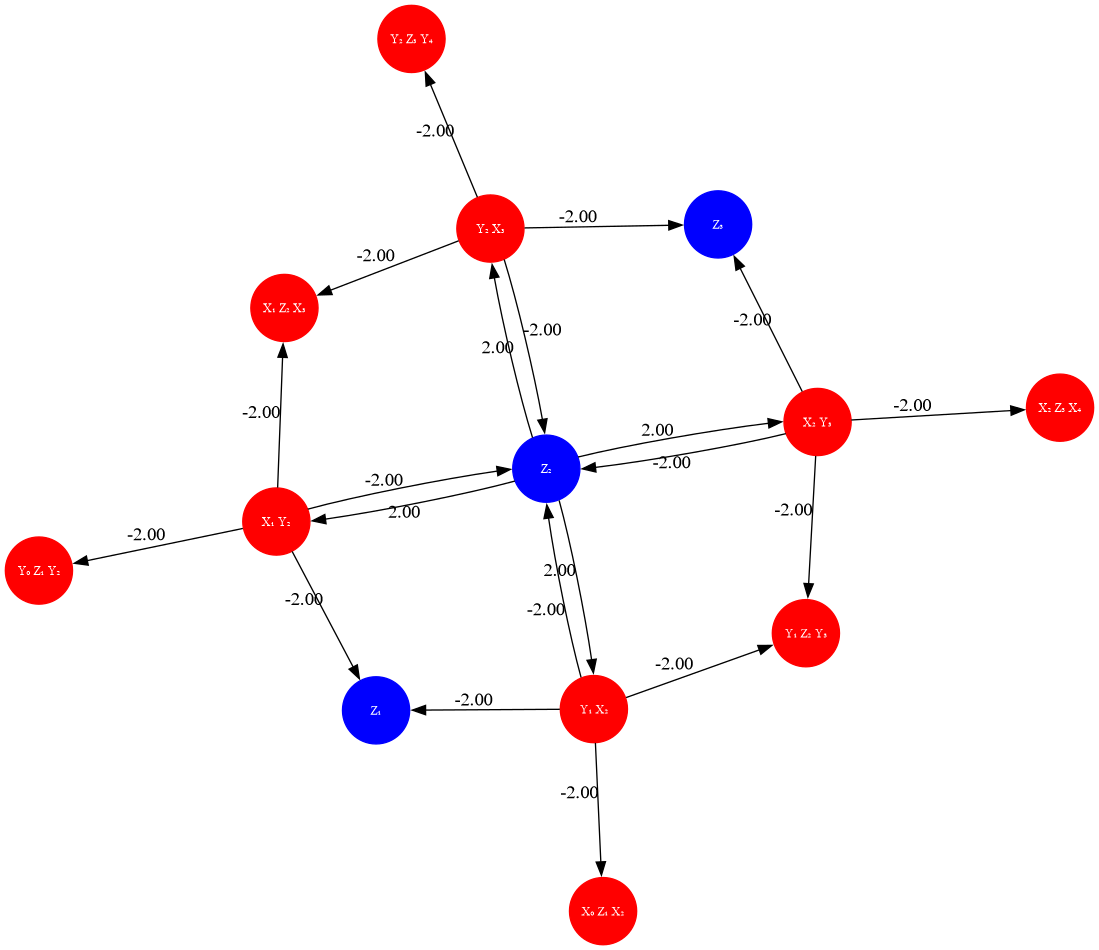

In [98]:
seed_str = 'Z'
pad_width = 2
padded_seed = 'I'*pad_width + seed_str + 'I'*pad_width
ham = generate_dq_hamiltonian(n=len(padded_seed))
root_idx = 0  # since seed is the first node added

graph, label_map = generate_louivillian_graph(padded_seed, ham, depth=2, corr_cutoff=7, max_nodes=100000, directed=True)
graphviz_draw(graph, node_attr_fn=node_attr, edge_attr_fn=edge_attr, method='sfdp')

In [99]:
chain_mat =  rx.adjacency_matrix(graph, weight_fn= lambda x: x).T

# Example usage with the notebook's variables:
n = chain_mat.shape[0]
A0 = np.zeros(n)
print(chain_mat)
A0[0] = 1.0     # set initial occupancy on the root node (root_idx exists in the notebook)

times = np.linspace(0.0, 10, 100)  # adjust as needed
A_t = solve_chain_time_series(chain_mat, A0, times,max_step=0.001)

# print a small summary
print("A(t) shape:", A_t.shape)
print("A(0) :", A_t[0])     # initial adjacency matrix at 0 time

[[ 0. -2. -2. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -2.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.  0.]]
A(t) shape: (100, 13)
A(0) : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [100]:
from collections import defaultdict
import itertools
from itertools import product

buckets = defaultdict(list)
for label, idx in label_map.items():
    key = tuple(c if c in "IZ" else '*' for c in label)
    buckets[key].append(label)

print(buckets)

defaultdict(<class 'list'>, {('I', 'I', 'Z', 'I', 'I'): ['IIZII'], ('I', '*', '*', 'I', 'I'): [np.str_('IYXII'), np.str_('IXYII')], ('I', 'I', '*', '*', 'I'): [np.str_('IIYXI'), np.str_('IIXYI')], ('I', 'Z', 'I', 'I', 'I'): [np.str_('IZIII')], ('*', 'Z', '*', 'I', 'I'): [np.str_('XZXII'), np.str_('YZYII')], ('I', '*', 'Z', '*', 'I'): [np.str_('IYZYI'), np.str_('IXZXI')], ('I', 'I', 'I', 'Z', 'I'): [np.str_('IIIZI')], ('I', 'I', '*', 'Z', '*'): [np.str_('IIYZY'), np.str_('IIXZX')]})


#### Hidden Debug

In [101]:
DEBUG = True

from collections import defaultdict
from itertools import product
import numpy as np

pauli = {
    'I': [(1,'I')], 'Z': [(1,'Z')],
    'X': [(1,'P'), (1,'M')],
    'Y': [(-1j,'P'), (1j,'M')]
}

# --- MQC construction ---
mqc = defaultdict(lambda: np.zeros(len(times)))

for key, labels in buckets.items():
    acc = defaultdict(lambda: np.zeros(len(times), dtype=np.complex128))

    if DEBUG:
        print(f"\n=== Bucket {key} ===")
        print("Labels:", labels)

    for label, idx in label_map.items():
        if label not in labels:
            continue

        if DEBUG:
            print(f"\nLabel {label}, idx={idx}")
            print("A_t[:, idx] (first 5):", A_t[:5, idx])

        for terms in product(*[pauli[c] for c in label]):
            coef, ops = 1, []
            for c,o in terms:
                coef *= c
                ops.append(o)
            ops = ''.join(ops)

            if DEBUG:
                print(f"  term {ops}, coef={coef:+g}")

            acc[ops] += coef * A_t[:, idx]

            if DEBUG:
                print("    acc[ops] (first 3):", acc[ops][:3])

    if DEBUG:
        print("\n--- After summing amplitudes ---")
        for ops, amp in acc.items():
            print(f"{ops}: |amp| first 3 =", np.abs(amp[:3]))

    for ops, amp_t in acc.items():
        order = ops.count('P') - ops.count('M')
        mqc[order] += np.abs(amp_t)**2

    if DEBUG:
        print("\n--- MQC by order ---")
        for order, trace in sorted(mqc.items()):
            print(f"Order {order}: I(t) first 3 =", trace[:3])

if DEBUG:
    print("\n--- MQC by order ---")
    for order, trace in sorted(mqc.items()):
        print(f"Order {order}: I(t) first 3 =", trace[:3])

if DEBUG:
    total_I = sum(np.sum(v) for v in mqc.values())
    print("Total MQC weight:", total_I)


=== Bucket ('I', 'I', 'Z', 'I', 'I') ===
Labels: ['IIZII']

Label IIZII, idx=0
A_t[:, idx] (first 5): [ 1.          0.91948007  0.69088721  0.35103397 -0.04534973]
  term IIZII, coef=+1
    acc[ops] (first 3): [1.        +0.j 0.91948007+0.j 0.69088721+0.j]

--- After summing amplitudes ---
IIZII: |amp| first 3 = [1.         0.91948007 0.69088721]

--- MQC by order ---
Order 0: I(t) first 3 = [1.         0.8454436  0.47732513]

=== Bucket ('I', '*', '*', 'I', 'I') ===
Labels: [np.str_('IYXII'), np.str_('IXYII')]

Label IYXII, idx=1
A_t[:, idx] (first 5): [0.         0.19656831 0.36148128 0.46818136 0.49948559]
  term IPPII, coef=+0-1j
    acc[ops] (first 3): [0.+0.j         0.-0.19656831j 0.-0.36148128j]
  term IPMII, coef=+0-1j
    acc[ops] (first 3): [0.+0.j         0.-0.19656831j 0.-0.36148128j]
  term IMPII, coef=+0+1j
    acc[ops] (first 3): [0.+0.j         0.+0.19656831j 0.+0.36148128j]
  term IMMII, coef=+0+1j
    acc[ops] (first 3): [0.+0.j         0.+0.19656831j 0.+0.36148128j

### Not Hidden

In [94]:
from collections import defaultdict
from itertools import product
import numpy as np

pauli = {
    'I': [(1,'I')], 'Z': [(1,'Z')],
    'X': [(1,'P'), (1,'M')],
    'Y': [(-1j,'P'), (1j,'M')]
}

for key, labels in buckets.items():
    acc = defaultdict(lambda: np.zeros(len(times), dtype=np.complex128))

    for label, idx in label_map.items():
        for terms in product(*[pauli[c] for c in label]):
            coef, ops = 1, []
            for c,o in terms:
                coef *= c
                ops.append(o)
            ops = ''.join(ops)
            acc[ops] += coef * A_t[:,idx]
            #print(acc)
    

    mqc = {}
    for ops, amp_t in acc.items():
        order = ops.count('P') - ops.count('M')
        if order not in mqc:
            mqc[order] = np.zeros(len(times))
        mqc[order] += np.abs(amp_t)**2

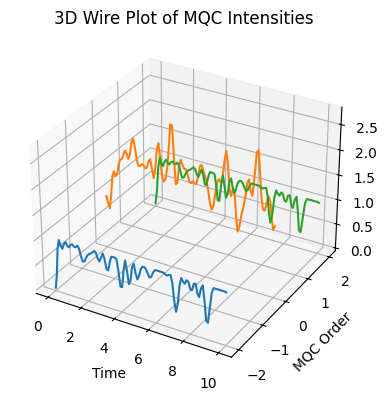

In [97]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

orders = sorted(mqc.keys())
Z = np.vstack([mqc[o] for o in orders])

for i, o in enumerate(orders):
    ax.plot(times, np.full_like(times, o), Z[i])

ax.set_xlabel("Time")
ax.set_ylabel("MQC Order")
ax.set_zlabel("Intensity")
ax.set_title("3D Wire Plot of MQC Intensities")

plt.tight_layout()
plt.show()


In [ ]:
seed_str = 'X'
pad_width = 9
padded_seed = 'I'*pad_width + seed_str + 'I'*pad_width
ham = generate_dipole_hamiltonian(n=len(padded_seed))
root_idx = 0  # since seed is the first node added

graph_2, label_map_2 = generate_louivillian_graph(padded_seed, ham, depth=2, corr_cutoff=3, max_nodes=100000, directed=True)
graphviz_draw(graph_2, node_attr_fn=node_attr, edge_attr_fn=edge_attr, method='sfdp')